In [73]:
pip install mplsoccer

In [74]:
from mplsoccer import PyPizza
import matplotlib.pyplot as plt
import pandas as pd

from sqlalchemy import create_engine, select
from sqlalchemy import text
from sqlalchemy.orm import sessionmaker

import glob
import os

pd.set_option('display.max_rows',30)
pd.set_option('display.max_columns',None)

In [75]:
# Configuración de la conexión a PostgreSQL
usuario = "avnadmin"
contrasena = "AVNS_Snql1CSp1zYrJCH6cXE"
servidor = "my-database-pg-my-data22.f.aivencloud.com"
puerto = "13676"
base_datos = "my_wyscout"

# Crea la cadena de conexión
conexion_str = f'postgresql+psycopg2://{usuario}:{contrasena}@{servidor}:{puerto}/{base_datos}'
engine = create_engine(conexion_str)

In [76]:
s_sql = text("""SELECT "Competición", "Temporada", "Posición Principal",	"Jugador", "Equipo", "Equipo durante el período seleccionado", "Posición específica",
	"Edad", "Valor de mercado", "Vencimiento contrato", "Partidos jugados", "Minutos jugados", "Goles", "xG", "Asistencias", "xA", "Duelos/90",
	"Duelos ganados %", "País de nacimiento", "Pasaporte", "Pie", "Altura", "Peso", "En préstamo", "Acciones defensivas realizadas/90", "Duelos defensivos/90", "Duelos defensivos ganados %",
	"Duelos aéreos/90", "Duelos aéreos ganados %", "Entradas/90", "Acciones de ataque exitosas/90", "Asistencias/90", "Asistencias/90.1",
    "Ataque en profundidad/90", "Carreras en progresión/90", "Centros desde el último tercio/90", "Centros desde la banda derecha/90",
    "Centros/90",
	"Desmarques/90", "Duelos aéreos/90.1", "Duelos atacantes ganados %", "Duelos atacantes/90", "Faltas recibidas/90", "Faltas/90",
	"Goles (excepto los penaltis)", "Goles de cabeza/90", "Goles evitados", "Goles hechos %", "Goles recibidos/90", "Goles/90",
	 "Interceptaciones/90", "Jugadas claves/90", "Longitud media pases, m",
    "Longitud media pases largos, m", "Pais_Comp", 	"Paradas %", "Pases al área de penalti/90",
    "Pases cortos / medios/90", "Pases en el último tercio/90", "Pases hacia adelante/90", "Pases hacía atrás recibidos del arquero/90",
	"Pases hacía el área pequeña %", "Pases largos recibidos/90", "Pases largos/90", "Pases laterales/90", "Pases progresivos/90",
    "Pases recibidos/90", "Pases/90", "Penaltis a favor", "Penaltis realizados %", "Porterías imbatidas/90",
    "Posesión conquistada después de una interceptación", "Precisión centros %", "Precisión centros desde la banda derecha %",
    "Precisión centros desde la banda izquierda %", "Precisión pases %", "Precisión pases cortos / medios %",
	"Precisión pases en el último tercio %", "Precisión pases en profundidad %", "Precisión pases hacia adelante %",
    "Precision pases hacia atrás %",  "Precisión pases laterales %", "Precisión pases progresivos %", "Regates realizados %", "Regates/90",
    "Remates en contra", "Remates en contra/90", "Remates", "Remates/90",
	"Salidas/90", "Second assists/90", "Tarjetas amarillas", "Tarjetas rojas", "Tarjetas rojas/90", "Third assists/90",
    "Tiros a la portería %", "Tiros interceptados/90", "Tiros libres directos %", "Tiros libres directos/90", "Tiros libres/90",
    "Toques en el área de penalti/90", "xA/90",  "xG en contra", "xG en contra/90", "xG/90",
	"Goles, excepto los penaltis/90", "Posesión conquistada después de una entrada", "Aceleraciones/90", "Centros al área pequeña/90",
    "Centros desde la banda izquierda/90", "Córneres/90",
    "Fecha_Actualizacion",
    "Goles de cabeza", "Goles evitados/90", "Goles recibidos",
	"Pases en profundidad/90", "Pases hacia atrás/90", "Precisión desmarques %",
	"Precisión pases largos %", "Tarjetas amarillas/90"
from jugadores j
union
SELECT "Competición", "Temporada", "Posición Principal",	"Jugador", "Equipo", "Equipo durante el período seleccionado", "Posición específica",
	"Edad", "Valor de mercado", "Vencimiento contrato", "Partidos jugados", "Minutos jugados", "Goles", "xG", "Asistencias", "xA", "Duelos/90",
	"Duelos ganados %", "País de nacimiento", "Pasaporte", "Pie", "Altura", "Peso", "En préstamo", "Acciones defensivas realizadas/90", "Duelos defensivos/90", "Duelos defensivos ganados %",
	"Duelos aéreos/90", "Duelos aéreos ganados %", "Entradas/90", "Acciones de ataque exitosas/90", "Asistencias/90", "Asistencias/90.1",
    "Ataque en profundidad/90", "Carreras en progresión/90", "Centros desde el último tercio/90", "Centros desde la banda derecha/90",
    "Centros/90",
	"Desmarques/90", "Duelos aéreos/90.1", "Duelos atacantes ganados %", "Duelos atacantes/90", "Faltas recibidas/90", "Faltas/90",
	"Goles (excepto los penaltis)", "Goles de cabeza/90", "Goles evitados", "Goles hechos %", "Goles recibidos/90", "Goles/90",
	 "Interceptaciones/90", "Jugadas claves/90", "Longitud media pases, m",
    "Longitud media pases largos, m", "Pais_Comp", 	"Paradas %", "Pases al área de penalti/90",
    "Pases cortos / medios/90", "Pases en el último tercio/90", "Pases hacia adelante/90", "Pases hacía atrás recibidos del arquero/90",
	"Pases hacía el área pequeña %", "Pases largos recibidos/90", "Pases largos/90", "Pases laterales/90", "Pases progresivos/90",
    "Pases recibidos/90", "Pases/90", "Penaltis a favor", "Penaltis realizados %", "Porterías imbatidas/90",
    "Posesión conquistada después de una interceptación", "Precisión centros %", "Precisión centros desde la banda derecha %",
    "Precisión centros desde la banda izquierda %", "Precisión pases %", "Precisión pases cortos / medios %",
	"Precisión pases en el último tercio %", "Precisión pases en profundidad %", "Precisión pases hacia adelante %",
    "Precision pases hacia atrás %",  "Precisión pases laterales %", "Precisión pases progresivos %", "Regates realizados %", "Regates/90",
    "Remates en contra", "Remates en contra/90", "Remates", "Remates/90",
	"Salidas/90", "Second assists/90", "Tarjetas amarillas", "Tarjetas rojas", "Tarjetas rojas/90", "Third assists/90",
    "Tiros a la portería %", "Tiros interceptados/90", "Tiros libres directos %", "Tiros libres directos/90", "Tiros libres/90",
    "Toques en el área de penalti/90", "xA/90",  "xG en contra", "xG en contra/90", "xG/90",
	"Goles, excepto los penaltis/90", "Posesión conquistada después de una entrada", "Aceleraciones/90", "Centros al área pequeña/90",
    "Centros desde la banda izquierda/90", "Córneres/90",
    "Fecha_Actualizacion",
    "Goles de cabeza", "Goles evitados/90", "Goles recibidos",
	"Pases en profundidad/90", "Pases hacia atrás/90", "Precisión desmarques %",
	"Precisión pases largos %", "Tarjetas amarillas/90"
from hist_jugadores hj
;""")

In [82]:
# Ejecutar la consulta SQL
df = pd.read_sql(s_sql, conexion_str)  # Cargar resultados en un DataFrame

In [85]:
df_players = df.copy()
#hacer copia para no perder el original
df_players = df_players.drop_duplicates()

In [111]:
fase_defensiva = ['Acciones defensivas realizadas/90','Duelos aéreos/90',
                'Duelos aéreos ganados %','Duelos defensivos ganados %','Duelos defensivos/90','Entradas/90',
                'Faltas/90','Interceptaciones/90','Posesión conquistada después de una entrada',
                'Posesión conquistada después de una interceptación','Tarjetas amarillas','Tarjetas amarillas/90',
                'Tarjetas rojas','Tarjetas rojas/90','Tiros interceptados/90']

abp = ['Córneres/90','Penaltis a favor','Penaltis realizados %','Tiros libres directos %',
       'Tiros libres directos/90','Tiros libres/90']

acc_ofensivas = ['Acciones de ataque exitosas/90','Aceleraciones/90','Asistencias','Asistencias/90',
                'Carreras en progresión/90','Centros al área pequeña/90','Centros desde la banda derecha/90',
                'Centros desde la banda izquierda/90','Centros/90','Duelos atacantes ganados %',
                'Duelos atacantes/90','Faltas recibidas/90','Goles','Goles (excepto los penaltis)',
                'Goles de cabeza','Goles de cabeza/90','Goles hechos %','Goles, excepto los penaltis/90',
                'Goles/90','Pases largos recibidos/90','Pases recibidos /90','Precisión centros %',
                'Precisión centros desde la banda derecha %','Precisión centros desde la banda izquierda %',
                'Regates realizados %','Regates/90','Remates','Remates/90','Tiros a la portería %',
                'Toques en el área de penalti/90','xG','xG/90']

fisica = ['Total Distance per 90','Running Distance per 90 (15-20 km/h)','HSR Distance per 90 (20-25 km/h)',
          'Sprinting Distance per 90 (+25 km/h)','HI Distance per 90 (+20 km/h)','Meter/Min','Max Speed (km/h)',
          'Count Medium Acceleration per 90 (1.5 m/s² to 3 m/s²)','Count High Acceleration per 90 (+3 m/s²)',
          'Count Medium Deceleration per 90 (-1.5 m/s² to -3 m/s²)','Count High Deceleration per 90 (-3 m/s²)',
          'Count HSR per 90 (20-25 km/h)','Count Sprint per 90 (+25 km/h)','Count HI per 90 (+20 km/h)']

jugadas_clave = ['Asistencias','Asistencias/90',
                'Ataque en profundidad/90','Centros desde el último tercio/90','Desmarques/90',
                'Jugadas claves/90','Pases al área de penalti/90','Pases en el último tercio/90',
                'Pases en profundidad/90','Pases hacía el área pequeña %','Pases progresivos/90',
                'Precisión desmarques %','Precisión pases en el último tercio %',
                'Precisión pases en profundidad %','Precisión pases progresivos %','Second assists/90',
                'Third assists/90','xA','xA/90']

organizacion = ['Longitud media pases largos, m','Longitud media pases, m','Pases cortos / medios /90',
                'Pases hacia adelante/90','Pases hacia atrás/90','Pases largos/90','Pases laterales/90',
                'Pases/90','Precisión pases %','Precisión pases cortos / medios %',
                'Precisión pases hacia adelante %','Precision pases hacia atrás %','Precisión pases largos %',
                'Precisión pases laterales %']

portero = ['Acciones defensivas realizadas/90','Duelos aéreos/90',
          'Duelos aéreos ganados %','Duelos defensivos ganados %','Duelos ganados %','Goles evitados',
          'Goles evitados/90','Goles recibidos','Goles recibidos/90','Longitud media pases largos, m',
          'Longitud media pases, m','Paradas %','Pases hacia adelante/90',
          'Pases hacía atrás recibidos del arquero/90','Pases hacia atrás/90','Pases largos/90',
          'Pases laterales/90','Pases/90','Porterías imbatidas en los 90','Precisión pases %',
          'Precisión pases cortos / medios %','Precisión pases hacia adelante %',
          'Precision pases hacia atrás %','Precisión pases largos %','Precisión pases laterales %',
          'Remates en contra','Remates en contra/90','Salidas/90','xG en contra','xG en contra/90']

Finalización = ['Goles', 'Goles (excepto los penaltis)', 'Goles de cabeza', 'Goles de cabeza/90',
                'Goles hechos %', 'Goles, excepto los penaltis/90', 'Goles/90', 'Remates', 'Remates/90',
                'Tiros a la portería %', 'xG/90'
                ]

Delantero = ['Goles', 'Goles/90', 'Tiros a la portería %', 'xG/90', 'xA/90', 'Remates/90',
             'Toques en el área de penalti/90', 'Regates realizados %', 'Regates/90',
             'Duelos atacantes ganados %', 'Duelos aéreos ganados %',
            ]

Extremo = ['Regates realizados %', 'Centros desde la banda izquierda/90', 'Centros desde la banda derecha/90',
           'Precisión centros desde la banda derecha %','Precisión centros desde la banda izquierda %',
           'Duelos atacantes ganados %', 'Goles', 'xG/90', 'Aceleraciones/90'
          ]

In [112]:
metrica = Delantero
temp_ult = "2024-2025"

In [100]:
#Filtrar última temporada completa
df_ult_temp = df_players[(df_players['Temporada'] == temp_ult)
                        ]
df_ult_temp.head(1)

,Competición,Temporada,Posición Principal,Jugador,Equipo,Equipo durante el período seleccionado,Posición específica,Edad,Valor de mercado,Vencimiento contrato,Partidos jugados,Minutos jugados,Goles,xG,Asistencias,xA,Duelos/90,Duelos ganados %,País de nacimiento,Pasaporte,Pie,Altura,Peso,En préstamo,Acciones defensivas realizadas/90,Duelos defensivos/90,Duelos defensivos ganados %,Duelos aéreos/90,Duelos aéreos ganados %,Entradas/90,Acciones de ataque exitosas/90,Asistencias/90,Asistencias/90.1,Ataque en profundidad/90,Carreras en progresión/90,Centros desde el último tercio/90,Centros desde la banda derecha/90,Centros/90,Desmarques/90,Duelos aéreos/90.1,Duelos atacantes ganados %,Duelos atacantes/90,Faltas recibidas/90,Faltas/90,Goles (excepto los penaltis),Goles de cabeza/90,Goles evitados,Goles hechos %,Goles recibidos/90,Goles/90,Interceptaciones/90,Jugadas claves/90,"Longitud media pases, m","Longitud media pases largos, m",Pais_Comp,Paradas %,Pases al área de penalti/90,Pases cortos / medios/90,Pases en el último tercio/90,Pases hacia adelante/90,Pases hacía atrás recibidos del arquero/90,Pases hacía el área pequeña %,Pases largos recibidos/90,Pases largos/90,Pases laterales/90,Pases progresivos/90,Pases recibidos/90,Pases/90,Penaltis a favor,Penaltis realizados %,Porterías imbatidas/90,Posesión conquistada después de una interceptación,Precisión centros %,Precisión centros desde la banda derecha %,Precisión centros desde la banda izquierda %,Precisión pases %,Precisión pases cortos / medios %,Precisión pases en el último tercio %,Precisión pases en profundidad %,Precisión pases hacia adelante %,Precision pases hacia atrás %,Precisión pases laterales %,Precisión pases progresivos %,Regates realizados %,Regates/90,Remates en contra,Remates en contra/90,Remates,Remates/90,Salidas/90,Second assists/90,Tarjetas amarillas,Tarjetas rojas,Tarjetas rojas/90,Third assists/90,Tiros a la portería %,Tiros interceptados/90,Tiros libres directos %,Tiros libres directos/90,Tiros libres/90,Toques en el área de penalti/90,xA/90,xG en contra,xG en contra/90,xG/90,"Goles, excepto los penaltis/90",Posesión conquistada después de una entrada,Aceleraciones/90,Centros al área pequeña/90,Centros desde la banda izquierda/90,Córneres/90,Fecha_Actualizacion,Goles de cabeza,Goles evitados/90,Goles recibidos,Pases en profundidad/90,Pases hacia atrás/90,Precisión desmarques %,Precisión pases largos %,Tarjetas amarillas/90
6723,1DIVI,2024-2025,Central,A. Abqar,Deportivo Alavés,Deportivo Alavés,RCB,26,7500000,2025-06-30,29,2747,0,1.50,1,0.15,11.99,57.10,Morocco,Morocco,derecho,188,80,no,7.96,5.14,64.33,3.08,52.13,0.16,0.16,0.03,0.13,0.39,0.79,0.07,0.10,0.13,0.10,NaN,53.13,1.05,1.02,1.57,0,0.00,NaN,0.00,NaN,0.00,4.49,0.03,25.70,45.39,ESP,0.00,1.08,23.26,6.16,12.58,1.87,36.36,0.23,6.09,12.71,5.83,17.86,29.45,0,0.00,0,6.04,50.00,66.67,0.00,82.09,90.85,54.79,42.11,67.19,100.00,92.01,73.60,33.33,0.20,0,NaN,10,0.33,NaN,0.03,13,0,0.00,0.03,10.00,0.56,0.00,0.00,0.10,0.69,0.00,0.00,0.00,0.05,0.00,0.22,0.10,0.00,0.03,0.00,2025-06-27 14:39:39.858545,0,NaN,0,0.62,2.23,0.00,48.92,0.43


In [87]:
#Buscar jugador PROMEDIO
df_ult_temp[df_ult_temp['Jugador'].str.contains('Promedio 1RFEF-Delantero')]

,Competición,Temporada,Posición Principal,Jugador,Equipo,Equipo durante el período seleccionado,Posición específica,Edad,Valor de mercado,Vencimiento contrato,Partidos jugados,Minutos jugados,Goles,xG,Asistencias,xA,Duelos/90,Duelos ganados %,País de nacimiento,Pasaporte,Pie,Altura,Peso,En préstamo,Acciones defensivas realizadas/90,Duelos defensivos/90,Duelos defensivos ganados %,Duelos aéreos/90,Duelos aéreos ganados %,Entradas/90,Acciones de ataque exitosas/90,Asistencias/90,Asistencias/90.1,Ataque en profundidad/90,Carreras en progresión/90,Centros desde el último tercio/90,Centros desde la banda derecha/90,Centros/90,Desmarques/90,Duelos aéreos/90.1,Duelos atacantes ganados %,Duelos atacantes/90,Faltas recibidas/90,Faltas/90,Goles (excepto los penaltis),Goles de cabeza/90,Goles evitados,Goles hechos %,Goles recibidos/90,Goles/90,Interceptaciones/90,Jugadas claves/90,"Longitud media pases, m","Longitud media pases largos, m",Pais_Comp,Paradas %,Pases al área de penalti/90,Pases cortos / medios/90,Pases en el último tercio/90,Pases hacia adelante/90,Pases hacía atrás recibidos del arquero/90,Pases hacía el área pequeña %,Pases largos recibidos/90,Pases largos/90,Pases laterales/90,Pases progresivos/90,Pases recibidos/90,Pases/90,Penaltis a favor,Penaltis realizados %,Porterías imbatidas/90,Posesión conquistada después de una interceptación,Precisión centros %,Precisión centros desde la banda derecha %,Precisión centros desde la banda izquierda %,Precisión pases %,Precisión pases cortos / medios %,Precisión pases en el último tercio %,Precisión pases en profundidad %,Precisión pases hacia adelante %,Precision pases hacia atrás %,Precisión pases laterales %,Precisión pases progresivos %,Regates realizados %,Regates/90,Remates en contra,Remates en contra/90,Remates,Remates/90,Salidas/90,Second assists/90,Tarjetas amarillas,Tarjetas rojas,Tarjetas rojas/90,Third assists/90,Tiros a la portería %,Tiros interceptados/90,Tiros libres directos %,Tiros libres directos/90,Tiros libres/90,Toques en el área de penalti/90,xA/90,xG en contra,xG en contra/90,xG/90,"Goles, excepto los penaltis/90",Posesión conquistada después de una entrada,Aceleraciones/90,Centros al área pequeña/90,Centros desde la banda izquierda/90,Córneres/90,Fecha_Actualizacion,Goles de cabeza,Goles evitados/90,Goles recibidos,Pases en profundidad/90,Pases hacia atrás/90,Precisión desmarques %,Precisión pases largos %,Tarjetas amarillas/90
12190,1RFEF,2024-2025,Delantero,Promedio 1RFEF-Delantero,Promedio,Promedio,Promedio,24,172208,None,20,1167,4,3.88,1,0.85,22.30,36.40,None,None,None,0,0,None,3.78,3.74,55.02,5.35,35.47,0.15,2.10,0.06,0.58,0.52,1.00,0.24,0.53,0.95,0.11,NaN,30.87,9.14,1.45,1.60,4,0.05,NaN,13.59,NaN,0.26,1.54,0.22,15.36,11.39,ESP,0.00,1.16,14.12,1.75,3.66,0.06,38.76,1.59,0.87,4.63,1.87,10.55,15.90,1,20.18,0,2.27,22.86,20.36,21.49,71.56,76.11,55.84,24.61,55.47,86.34,71.10,61.02,46.93,2.17,0,NaN,25,1.76,NaN,0.03,3,0,0.01,0.01,41.04,0.08,6.68,0.02,0.12,2.61,0.06,0.00,0.00,0.28,0.23,0.23,0.18,0.12,0.40,0.21,2025-09-24 13:32:18.787562,1,NaN,0,0.18,4.10,22.77,42.47,0.23


In [88]:
#PREMEDIO
jugador_prom = df_ult_temp[(df_ult_temp['Jugador'] == "Promedio 1RFEF-Delantero")
                          ]
jugador_prom

,Competición,Temporada,Posición Principal,Jugador,Equipo,Equipo durante el período seleccionado,Posición específica,Edad,Valor de mercado,Vencimiento contrato,Partidos jugados,Minutos jugados,Goles,xG,Asistencias,xA,Duelos/90,Duelos ganados %,País de nacimiento,Pasaporte,Pie,Altura,Peso,En préstamo,Acciones defensivas realizadas/90,Duelos defensivos/90,Duelos defensivos ganados %,Duelos aéreos/90,Duelos aéreos ganados %,Entradas/90,Acciones de ataque exitosas/90,Asistencias/90,Asistencias/90.1,Ataque en profundidad/90,Carreras en progresión/90,Centros desde el último tercio/90,Centros desde la banda derecha/90,Centros/90,Desmarques/90,Duelos aéreos/90.1,Duelos atacantes ganados %,Duelos atacantes/90,Faltas recibidas/90,Faltas/90,Goles (excepto los penaltis),Goles de cabeza/90,Goles evitados,Goles hechos %,Goles recibidos/90,Goles/90,Interceptaciones/90,Jugadas claves/90,"Longitud media pases, m","Longitud media pases largos, m",Pais_Comp,Paradas %,Pases al área de penalti/90,Pases cortos / medios/90,Pases en el último tercio/90,Pases hacia adelante/90,Pases hacía atrás recibidos del arquero/90,Pases hacía el área pequeña %,Pases largos recibidos/90,Pases largos/90,Pases laterales/90,Pases progresivos/90,Pases recibidos/90,Pases/90,Penaltis a favor,Penaltis realizados %,Porterías imbatidas/90,Posesión conquistada después de una interceptación,Precisión centros %,Precisión centros desde la banda derecha %,Precisión centros desde la banda izquierda %,Precisión pases %,Precisión pases cortos / medios %,Precisión pases en el último tercio %,Precisión pases en profundidad %,Precisión pases hacia adelante %,Precision pases hacia atrás %,Precisión pases laterales %,Precisión pases progresivos %,Regates realizados %,Regates/90,Remates en contra,Remates en contra/90,Remates,Remates/90,Salidas/90,Second assists/90,Tarjetas amarillas,Tarjetas rojas,Tarjetas rojas/90,Third assists/90,Tiros a la portería %,Tiros interceptados/90,Tiros libres directos %,Tiros libres directos/90,Tiros libres/90,Toques en el área de penalti/90,xA/90,xG en contra,xG en contra/90,xG/90,"Goles, excepto los penaltis/90",Posesión conquistada después de una entrada,Aceleraciones/90,Centros al área pequeña/90,Centros desde la banda izquierda/90,Córneres/90,Fecha_Actualizacion,Goles de cabeza,Goles evitados/90,Goles recibidos,Pases en profundidad/90,Pases hacia atrás/90,Precisión desmarques %,Precisión pases largos %,Tarjetas amarillas/90
12190,1RFEF,2024-2025,Delantero,Promedio 1RFEF-Delantero,Promedio,Promedio,Promedio,24,172208,None,20,1167,4,3.88,1,0.85,22.30,36.40,None,None,None,0,0,None,3.78,3.74,55.02,5.35,35.47,0.15,2.10,0.06,0.58,0.52,1.00,0.24,0.53,0.95,0.11,NaN,30.87,9.14,1.45,1.60,4,0.05,NaN,13.59,NaN,0.26,1.54,0.22,15.36,11.39,ESP,0.00,1.16,14.12,1.75,3.66,0.06,38.76,1.59,0.87,4.63,1.87,10.55,15.90,1,20.18,0,2.27,22.86,20.36,21.49,71.56,76.11,55.84,24.61,55.47,86.34,71.10,61.02,46.93,2.17,0,NaN,25,1.76,NaN,0.03,3,0,0.01,0.01,41.04,0.08,6.68,0.02,0.12,2.61,0.06,0.00,0.00,0.28,0.23,0.23,0.18,0.12,0.40,0.21,2025-09-24 13:32:18.787562,1,NaN,0,0.18,4.10,22.77,42.47,0.23


In [89]:
#DEPENDE DE LA POSICIÓN DEL JUGADOR
jugador_prom = jugador_prom[["Jugador", "Temporada", "Equipo durante el período seleccionado"] + metrica].dropna().reset_index(drop=True).sort_values(by='Temporada', ascending=True)
jugador_prom

,Jugador,Temporada,Equipo durante el período seleccionado,Goles,Goles/90,Tiros a la portería %,xG/90,xA/90,Remates/90,Regates realizados %,Regates/90,Toques en el área de penalti/90,Duelos atacantes ganados %,Duelos aéreos ganados %
0,Promedio 1RFEF-Delantero,2024-2025,Promedio,4,0.26,41.04,0.28,0.06,1.76,46.93,2.17,2.61,30.87,35.47


In [101]:
nombre_prom = jugador_prom["Jugador"].values[0]
equipo_prom = jugador_prom["Equipo durante el período seleccionado"].values[0]


print(nombre_prom)
print(equipo_prom)
print(temp_ult)

Promedio 1RFEF-Delantero
Promedio
2024-2025


In [90]:
#Buscar jugador para ver su proyección futura
jugador_analizado = df_ult_temp[(df_ult_temp['Jugador'] == "C. De la Nava")
                              ]
jugador_analizado

,Competición,Temporada,Posición Principal,Jugador,Equipo,Equipo durante el período seleccionado,Posición específica,Edad,Valor de mercado,Vencimiento contrato,Partidos jugados,Minutos jugados,Goles,xG,Asistencias,xA,Duelos/90,Duelos ganados %,País de nacimiento,Pasaporte,Pie,Altura,Peso,En préstamo,Acciones defensivas realizadas/90,Duelos defensivos/90,Duelos defensivos ganados %,Duelos aéreos/90,Duelos aéreos ganados %,Entradas/90,Acciones de ataque exitosas/90,Asistencias/90,Asistencias/90.1,Ataque en profundidad/90,Carreras en progresión/90,Centros desde el último tercio/90,Centros desde la banda derecha/90,Centros/90,Desmarques/90,Duelos aéreos/90.1,Duelos atacantes ganados %,Duelos atacantes/90,Faltas recibidas/90,Faltas/90,Goles (excepto los penaltis),Goles de cabeza/90,Goles evitados,Goles hechos %,Goles recibidos/90,Goles/90,Interceptaciones/90,Jugadas claves/90,"Longitud media pases, m","Longitud media pases largos, m",Pais_Comp,Paradas %,Pases al área de penalti/90,Pases cortos / medios/90,Pases en el último tercio/90,Pases hacia adelante/90,Pases hacía atrás recibidos del arquero/90,Pases hacía el área pequeña %,Pases largos recibidos/90,Pases largos/90,Pases laterales/90,Pases progresivos/90,Pases recibidos/90,Pases/90,Penaltis a favor,Penaltis realizados %,Porterías imbatidas/90,Posesión conquistada después de una interceptación,Precisión centros %,Precisión centros desde la banda derecha %,Precisión centros desde la banda izquierda %,Precisión pases %,Precisión pases cortos / medios %,Precisión pases en el último tercio %,Precisión pases en profundidad %,Precisión pases hacia adelante %,Precision pases hacia atrás %,Precisión pases laterales %,Precisión pases progresivos %,Regates realizados %,Regates/90,Remates en contra,Remates en contra/90,Remates,Remates/90,Salidas/90,Second assists/90,Tarjetas amarillas,Tarjetas rojas,Tarjetas rojas/90,Third assists/90,Tiros a la portería %,Tiros interceptados/90,Tiros libres directos %,Tiros libres directos/90,Tiros libres/90,Toques en el área de penalti/90,xA/90,xG en contra,xG en contra/90,xG/90,"Goles, excepto los penaltis/90",Posesión conquistada después de una entrada,Aceleraciones/90,Centros al área pequeña/90,Centros desde la banda izquierda/90,Córneres/90,Fecha_Actualizacion,Goles de cabeza,Goles evitados/90,Goles recibidos,Pases en profundidad/90,Pases hacia atrás/90,Precisión desmarques %,Precisión pases largos %,Tarjetas amarillas/90
12062,1RFEF,2024-2025,Delantero,C. De la Nava,Unionistas de Salamanca,Unionistas de Salamanca,CF,32,200000,2026-06-30,33,2069,6,3.65,2,1.18,27.58,39.12,Spain,Spain,derecho,187,80,no,5.61,4.22,53.61,9.79,44.89,0.22,0.91,0.09,0.70,0.65,0.48,0.13,0.09,0.43,0.09,NaN,28.50,9.31,1.87,1.57,6,0.09,NaN,25.00,NaN,0.26,3.13,0.22,17.40,24.55,ESP,0.00,0.96,21.71,3.39,5.79,0.22,40.91,1.96,1.74,6.61,2.83,14.53,23.88,0,0.00,0,3.76,30.00,0.00,37.50,77.05,79.56,64.10,55.56,57.14,91.28,82.24,61.54,37.50,0.70,0,NaN,24,1.04,NaN,0.09,6,0,0.00,0.00,50.00,0.35,0.00,0.00,0.00,1.91,0.05,0.00,0.00,0.16,0.26,0.26,0.04,0.00,0.35,0.00,2025-06-27 14:39:39.858545,2,NaN,0,0.39,6.48,0.00,57.50,0.26


In [91]:
#DEPENDE DE LA POSICIÓN DEL JUGADOR
jugador_analizado = jugador_analizado[["Jugador", "Temporada", "Equipo durante el período seleccionado"] + metrica].dropna().reset_index(drop=True).sort_values(by='Temporada', ascending=True)
jugador_analizado

,Jugador,Temporada,Equipo durante el período seleccionado,Goles,Goles/90,Tiros a la portería %,xG/90,xA/90,Remates/90,Regates realizados %,Regates/90,Toques en el área de penalti/90,Duelos atacantes ganados %,Duelos aéreos ganados %
0,C. De la Nava,2024-2025,Unionistas de Salamanca,6,0.26,50.00,0.16,0.05,1.04,37.50,0.70,1.91,28.50,44.89


In [103]:
nombre_jug = jugador_analizado["Jugador"].values[0]
equipo_jug = jugador_analizado["Equipo durante el período seleccionado"].values[0]

print(nombre_jug)
print(equipo_jug)
print(temp_ult)

C. De la Nava
Unionistas de Salamanca
2024-2025


In [ ]:
# Concatenar histórico + predicción
#df_final = pd.concat([jugador_analizado, jugador_prom], ignore_index=True)
#df_final

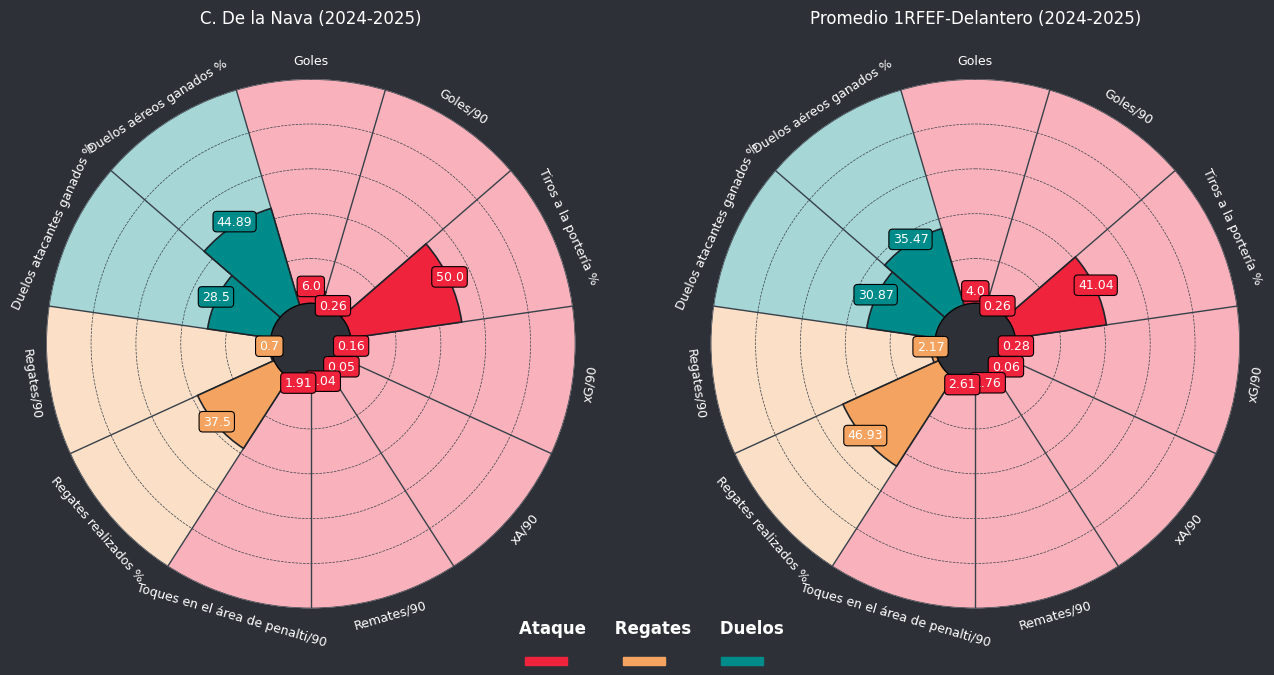

In [119]:
# ================================
# Radar comparativo (PyPizza)
# ================================

# --- Estilo ---
BG="#2d3137"; TIT="#F4A460"; KEY="#008B8B"; IMPACT="#ef233c"; WHITE="#ffffff"; BLACK='#000000'

params = metrica

slice_colors = [IMPACT]*7 + [TIT]*2 + [KEY]*2
value_colors = [WHITE]*len(params)

# --- Percentiles ---
jugador_vals = jugador_analizado[metrica].values.flatten().round(2)
prom_vals = jugador_prom[metrica].values.flatten().round(2)


# --- Figura lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7), facecolor=BG,
                         subplot_kw=dict(polar=True))

# --- Radar Jugador ---
baker1 = PyPizza(params=params, background_color=BG,
    straight_line_color="#38414a", straight_line_lw=1,
    last_circle_color="#38414a", last_circle_lw=1,
    other_circle_lw=0.5, other_circle_color="#38414a",
    inner_circle_size=18
)
baker1.make_pizza(
    jugador_vals, ax=axes[0],
    color_blank_space="same", slice_colors=slice_colors,
    value_colors=value_colors, value_bck_colors=slice_colors, blank_alpha=0.35,
    kwargs_slices=dict(edgecolor="#1f242a", linewidth=1.2, zorder=2),
    kwargs_params=dict(color=WHITE, fontsize=9, va="center"),
    kwargs_values=dict(
        color=WHITE, fontsize=9, zorder=3,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="black", edgecolor="black", lw=0.8
        )
    )
)
axes[0].set_title(nombre_jug + " (" + temp_ult + ")", color=WHITE, fontsize=12, pad=40)

# --- Radar Promedio ---
baker2 = PyPizza(params=params, background_color=BG,
    straight_line_color="#38414a", straight_line_lw=1,
    last_circle_color="#38414a", last_circle_lw=1,
    other_circle_lw=0.5, other_circle_color="#38414a",
    inner_circle_size=18
)
baker2.make_pizza(
    prom_vals, ax=axes[1],
    color_blank_space="same", slice_colors=slice_colors,
    value_colors=value_colors, value_bck_colors=slice_colors, blank_alpha=0.35,
    kwargs_slices=dict(edgecolor="#1f242a", linewidth=1.2, zorder=2),
    kwargs_params=dict(color=WHITE, fontsize=9, va="center"),
    kwargs_values=dict(
        color=BLACK, fontsize=9, zorder=3,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="black", edgecolor="black", lw=0.8
        )
    )
)
axes[1].set_title(nombre_prom + " (" + temp_ult + ")", color=WHITE, fontsize=12, pad=40)

# --- Leyenda bloques ---
fig.text(0.51, 0.10, "Ataque     Regates     Duelos",
         ha="center", color=WHITE, fontsize=12, weight="bold")
fig.patches.extend([
    plt.Rectangle((0.42, 0.055), 0.03, 0.012, color=IMPACT, transform=fig.transFigure, figure=fig),
    plt.Rectangle((0.49, 0.055), 0.03, 0.012, color=TIT,    transform=fig.transFigure, figure=fig),
    plt.Rectangle((0.56, 0.055), 0.03, 0.012, color=KEY,    transform=fig.transFigure, figure=fig),
])

plt.tight_layout(rect=[0.02,0.09,0.98,0.98])
#plt.savefig("M3.1.png", dpi=220, facecolor=BG)
plt.show()